In [8]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
pip install geodatasets

/var/folders/sg/cy13dc_j0vzg_r3xrvskyw500000gq/T/ipykernel_87964/3452843885.py:72: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


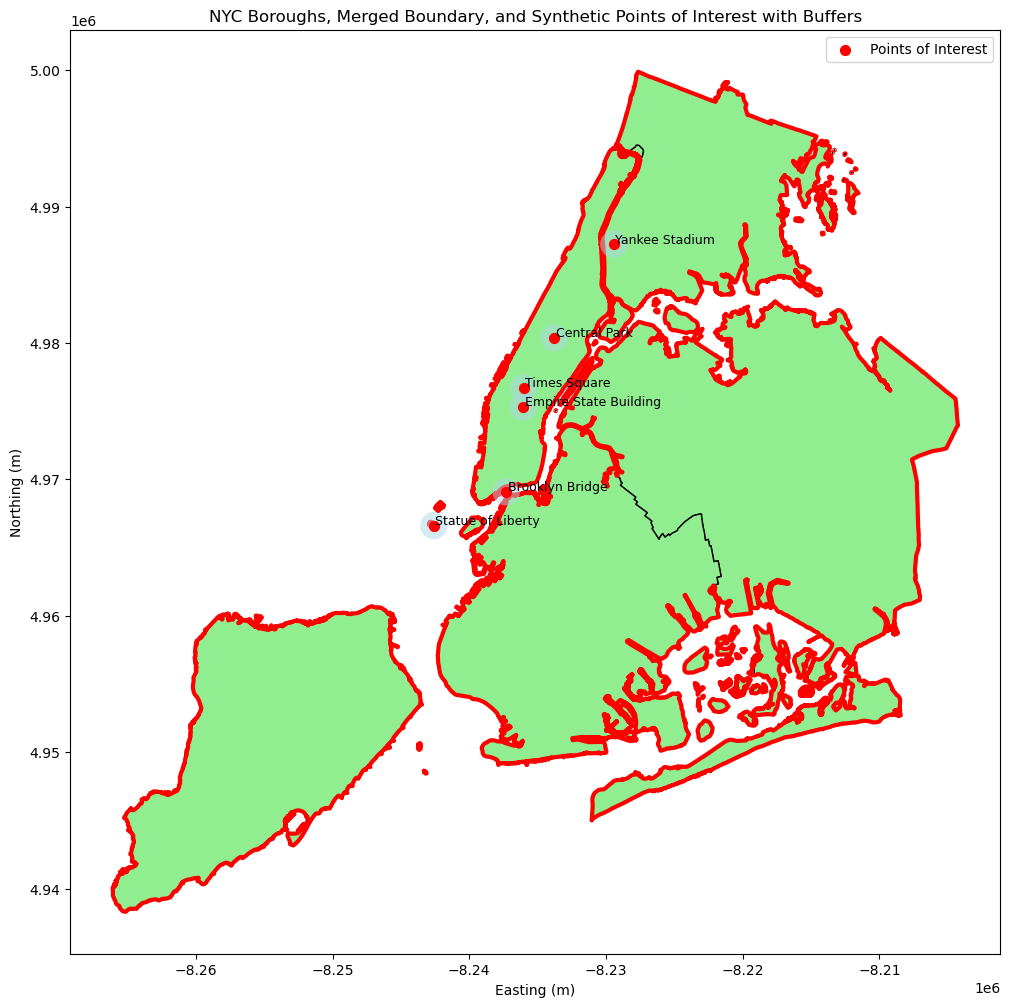

In [9]:
# task: plot points, buffered points and polygons on matplotlib 
# subtask buffer the points by 1000 meters 

from geodatasets import get_path
from shapely.geometry import Point

# Create synthetic points of interest (lat, lon approx locations within NYC)
# Coordinates are WGS84 (EPSG:4326), need to project later
poi_data = {
    "name": [
        "Statue of Liberty",
        "Times Square",
        "Central Park",
        "Brooklyn Bridge",
        "Empire State Building",
        "Yankee Stadium"
    ],
    "latitude": [
        40.6892, 40.7580, 40.7829, 40.7061, 40.7484, 40.8296
    ],
    "longitude": [
        -74.0445, -73.9855, -73.9654, -73.9969, -73.9857, -73.9262
    ]
}

# Create GeoDataFrame of points
pois_gpd = gpd.GeoDataFrame(
    poi_data,
    geometry=[Point(xy) for xy in zip(poi_data['longitude'], poi_data['latitude'])],
    crs='EPSG:4326'  # initial CRS
)

# Project the points to match nybb CRS (EPSG:3857)
pois_gpd = pois_gpd.to_crs(epsg=3857)

# Create buffers around POIs (e.g., 1000 meters = 1 km)
pois_gpd['buffer'] = pois_gpd.geometry.buffer(1000)

#################
# polygons 

# Load the geodatasets library with built in datasets,  NY boroughs (polygon)
path_to_nybb = get_path('nybb')
nybb = gpd.read_file(path_to_nybb)

# Project to EPSG:3857 (meters) for accurate spatial analysis
nybb = nybb.to_crs(epsg=3857)

# Dissolve all boroughs into a single polygon (NYC boundary)
nyc_boundary = nybb.dissolve()

# Plot 
fig, ax = plt.subplots(figsize=(12, 12))

# Plot boroughs with light green
nybb.plot(ax=ax, color='lightgreen', edgecolor='black', label='Boroughs')

# Plot merged NYC boundary with red border
nyc_boundary.plot(ax=ax, color='none', edgecolor='red', linewidth=3, label='Merged Boundary')

# Plot POI buffers (light blue, transparent)
pois_gpd['buffer'].plot(ax=ax, color='lightblue', alpha=0.5, label='1km Buffers')

# Plot POIs (red points)
pois_gpd.plot(ax=ax, color='red', markersize=50, label='Points of Interest')

# Annotate POIs with their names
for x, y, label in zip(pois_gpd.geometry.x, pois_gpd.geometry.y, pois_gpd['name']):
    ax.text(x + 100, y + 100, label, fontsize=9)

# add map elements, legend, title, coordinate system axes
plt.legend()
plt.title("NYC Boroughs, Merged Boundary, and Synthetic Points of Interest with Buffers")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.axis('equal')  # Equal scaling
plt.show()